### Stage 3: Polynomial and spline regression of the weekly free $b_1$ and $b_2$ for comparison with RF.

Fits polynomial (degree 2) and additive spline models for the weekly free
per-bite probabilities `b1_eff` and `b2_eff` (recovered from the weekly free-beta
fit), evaluates via leave-one-year-out CV, extracts interpretable coefficients,
and generates comparison figures.

Requires `scikit-learn, statsmodels, numpy, pandas, matplotlib`.

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import LeaveOneGroupOut

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
try:
    _SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter there is no __file__. Search downward for the 'regression'
    # folder that contains this notebook family (it has results/ and data/
    # siblings), so paths resolve regardless of the kernel launch directory.
    import pathlib
    _cwd = pathlib.Path(os.getcwd()).resolve()
    _reg = None
    for _p in _cwd.rglob("regression"):
        if not _p.is_dir():
            continue
        if (_p / "results").is_dir() and (_p / "data").is_dir():
            _reg = _p
            break
    if _reg is None:
        # Fallback: any regression dir under cwd
        for _p in _cwd.rglob("regression"):
            if _p.is_dir():
                _reg = _p
                break
    _SCRIPT_DIR = str(_reg) if _reg is not None else str(_cwd)
_DATA_DIR = os.path.join(_SCRIPT_DIR, "data")
_RESULTS_DIR = os.path.join(_SCRIPT_DIR, "results")
os.makedirs(_RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Feature / target definitions
# ---------------------------------------------------------------------------
# Core continuous features for the polynomial/spline models
CORE_FEATURES = [
    "temp_mean", "precip_mean", "umid_min_mean",
    "defor_clearcut_4wk", "defor_degradation_4wk",
    "defor_burnscar_4wk", "fire_counts_4wk",
    "sin_week", "cos_week",
]

# Full feature set includes one-hot year indicators
FULL_FEATURE_COLS = CORE_FEATURES + [f"year_{y}" for y in range(2017, 2024)]

TARGET_B1 = "b1_eff"
TARGET_B2 = "b2_eff"

In [3]:
def load_data():
    path = os.path.join(_DATA_DIR, "weekly_regression_valid.csv")
    df = pd.read_csv(path, parse_dates=["start_date"])
    cols_needed = FULL_FEATURE_COLS + [TARGET_B1, TARGET_B2]
    df = df.dropna(subset=cols_needed).copy()
    return df

def get_groups(df):
    return df["year"].values

In [4]:
# ---------------------------------------------------------------------------
# Polynomial regression
# ---------------------------------------------------------------------------

def polynomial_cv(X, y, groups, degree=2, alpha=1.0, target_name=""):
    """LOYO CV for polynomial regression."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []
    fold_years, fold_r2, fold_mae = [], [], []

    for train_idx, test_idx in logo.split(X_poly, y, groups):
        X_tr, X_te = X_poly[train_idx], X_poly[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        year = groups[test_idx][0]

        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2 = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)

        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        fold_years.append(int(year))
        fold_r2.append(r2)
        fold_mae.append(mae)

        print(f"  Poly({degree}) Year {year}: R²={r2:.4f}, MAE={mae:.6f}")

    overall_r2 = r2_score(y_true_all, y_pred_all)
    overall_mae = mean_absolute_error(y_true_all, y_pred_all)

    return {
        "fold_years": fold_years,
        "fold_r2": fold_r2,
        "fold_mae": fold_mae,
        "mean_r2": np.mean(fold_r2),
        "std_r2": np.std(fold_r2),
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "overall_r2": float(overall_r2),
        "overall_mae": float(overall_mae),
        "y_true": np.array(y_true_all),
        "y_pred": np.array(y_pred_all),
    }

In [5]:
# ---------------------------------------------------------------------------
# Additive spline model (natural cubic splines via manual basis)
# ---------------------------------------------------------------------------

def natural_cubic_basis(x, knots):
    """Construct natural cubic spline basis (no intercept column)."""
    K = len(knots)
    n = len(x)
    basis = np.zeros((n, K + 1))
    # Linear term
    basis[:, 0] = x
    # Cubic terms
    for j, t in enumerate(knots):
        pos = np.maximum(x - t, 0) ** 3
        basis[:, j + 1] = pos
    return basis

In [6]:
def build_spline_features(X_core, knots_dict):
    """Build spline basis for each core feature, concatenated."""
    n = X_core.shape[0]
    parts = []
    feat_names = []
    for col_idx, feat_name in enumerate(CORE_FEATURES):
        x = X_core[:, col_idx]
        knots = knots_dict.get(feat_name, [])
        if knots:
            basis = natural_cubic_basis(x, knots)
        else:
            basis = x.reshape(-1, 1)
        parts.append(basis)
        for k in range(basis.shape[1]):
            feat_names.append(f"{feat_name}_s{k}")
    return np.hstack(parts), feat_names

In [7]:
def spline_cv(X, y, groups, knots_dict, alpha=1.0, target_name=""):
    """LOYO CV for additive spline model."""
    X_spline, _ = build_spline_features(X, knots_dict)

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []
    fold_years, fold_r2, fold_mae = [], [], []

    for train_idx, test_idx in logo.split(X_spline, y, groups):
        X_tr, X_te = X_spline[train_idx], X_spline[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        year = groups[test_idx][0]

        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2 = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)

        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        fold_years.append(int(year))
        fold_r2.append(r2)
        fold_mae.append(mae)

        print(f"  Spline Year {year}: R²={r2:.4f}, MAE={mae:.6f}")

    overall_r2 = r2_score(y_true_all, y_pred_all)
    overall_mae = mean_absolute_error(y_true_all, y_pred_all)

    return {
        "fold_years": fold_years,
        "fold_r2": fold_r2,
        "fold_mae": fold_mae,
        "mean_r2": np.mean(fold_r2),
        "std_r2": np.std(fold_r2),
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "overall_r2": float(overall_r2),
        "overall_mae": float(overall_mae),
        "y_true": np.array(y_true_all),
        "y_pred": np.array(y_pred_all),
    }

In [8]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_predicted_vs_actual(cv_results, model_name, target_name):
    fig, ax = plt.subplots(figsize=(6, 6))
    y_true = cv_results["y_true"]
    y_pred = cv_results["y_pred"]

    ax.scatter(y_true, y_pred, alpha=0.5, s=30, edgecolors="black", linewidth=0.3,
               color="#DD8452")
    lims = [min(y_true.min(), y_pred.min()) * 0.9,
            max(y_true.max(), y_pred.max()) * 1.1]
    ax.plot(lims, lims, "--", color="red", linewidth=1, label="Perfect prediction")
    ax.set_xlabel(f"Actual {target_name}")
    ax.set_ylabel(f"Predicted {target_name}")
    ax.set_title(f"{model_name} — {target_name}\n"
                 f"R²={cv_results['overall_r2']:.4f}, MAE={cv_results['overall_mae']:.6f}")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [9]:
def plot_spline_terms(model, X_core, knots_dict, target_name):
    """Plot each spline term's contribution."""
    X_spline, feat_names = build_spline_features(X_core, knots_dict)

    # Find which columns in X_spline correspond to which feature
    col = 0
    for feat_name in CORE_FEATURES:
        n_knots = len(knots_dict.get(feat_name, []))
        n_cols = max(1, n_knots + 1) if n_knots else 1
        feat_cols = list(range(col, col + n_cols))

        x = X_core[:, CORE_FEATURES.index(feat_name)]
        x_range = np.linspace(x.min(), x.max(), 100)

        # Build spline basis for the grid
        if n_knots:
            basis = natural_cubic_basis(x_range, knots_dict[feat_name])
        else:
            basis = x_range.reshape(-1, 1)

        # Get coefficients for this feature's columns
        coefs = model.coef_[feat_cols]
        contribution = basis @ coefs

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(x_range, contribution, color="#4C72B0", linewidth=2)
        ax.scatter(x, np.zeros_like(x), alpha=0.1, s=5, color="gray", label="Data density")
        ax.set_xlabel(feat_name)
        ax.set_ylabel(f"Contribution to {target_name}")
        ax.set_title(f"Spline term: {feat_name} → {target_name}")
        ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        col += n_cols

    print(f"  Saved spline term plots for {target_name}")

In [10]:
def plot_model_comparison(cv_results_dict, target_name):
    """Bar chart comparing R² across models."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    models = list(cv_results_dict.keys())
    mean_r2 = [cv_results_dict[m]["mean_r2"] for m in models]
    std_r2 = [cv_results_dict[m]["std_r2"] for m in models]
    mean_mae = [cv_results_dict[m]["mean_mae"] for m in models]
    std_mae = [cv_results_dict[m]["std_mae"] for m in models]

    colors = ["#4C72B0", "#DD8452", "#55A868"]

    bars1 = ax1.bar(models, mean_r2, yerr=std_r2, color=colors[:len(models)],
                     edgecolor="black", linewidth=0.5, capsize=5)
    ax1.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set_ylabel("R² (mean ± std across folds)")
    ax1.set_title(f"Model Comparison — {target_name}")
    for bar, val in zip(bars1, mean_r2):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=9)

    bars2 = ax2.bar(models, mean_mae, yerr=std_mae, color=colors[:len(models)],
                     edgecolor="black", linewidth=0.5, capsize=5)
    ax2.set_ylabel("MAE (mean ± std across folds)")
    ax2.set_title(f"Model Comparison — {target_name}")
    for bar, val in zip(bars2, mean_mae):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Loading data...
  357 valid weeks

Model comparison for b1_eff

--- Polynomial (degree=2) ---
  Poly(2) Year 2017: R²=-1.4820, MAE=0.213014
  Poly(2) Year 2018: R²=-1.5165, MAE=0.206043
  Poly(2) Year 2019: R²=-4.3066, MAE=0.301668
  Poly(2) Year 2020: R²=-0.0848, MAE=0.122511
  Poly(2) Year 2021: R²=0.0382, MAE=0.126552
  Poly(2) Year 2022: R²=-0.5809, MAE=0.151366
  Poly(2) Year 2023: R²=-839318.3501, MAE=11.901370
  Aggregate R²=-6458.2242, MAE=1.893170

--- Polynomial (degree=3) ---
  Poly(3) Year 2017: R²=-17.8429, MAE=0.559228
  Poly(3) Year 2018: R²=-317.6111, MAE=2.726113
  Poly(3) Year 2019: R²=-36.9425, MAE=0.829076


C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6933396345870623e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.863692407589316e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6830914362367647e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8097119249196276e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site

  Poly(3) Year 2020: R²=-1296.9712, MAE=5.299947
  Poly(3) Year 2021: R²=-24.6797, MAE=0.787632
  Poly(3) Year 2022: R²=-536.9737, MAE=2.623694
  Poly(3) Year 2023: R²=-10079572157.5510, MAE=1076.732107
  Aggregate R²=-77549592.3229, MAE=158.670746

--- Additive Spline ---
  Spline Year 2017: R²=-1.5745, MAE=0.216986
  Spline Year 2018: R²=-0.1401, MAE=0.115137
  Spline Year 2019: R²=0.1635, MAE=0.095416
  Spline Year 2020: R²=0.1101, MAE=0.103860
  Spline Year 2021: R²=0.0724, MAE=0.119487
  Spline Year 2022: R²=-0.5601, MAE=0.167978
  Spline Year 2023: R²=-15478963167.6826, MAE=1400.672987
  Aggregate R²=-119090636.3598, MAE=204.136103

Spline coefficients:
  temp_mean_s0: -0.018213
  temp_mean_s1: -0.002055
  temp_mean_s2: 0.002925
  precip_mean_s0: 0.022642
  precip_mean_s1: -0.000563
  precip_mean_s2: 0.000908
  umid_min_mean_s0: -0.007594
  umid_min_mean_s1: -0.000092
  umid_min_mean_s2: 0.000639
  defor_clearcut_4wk_s0: 0.038187
  defor_clearcut_4wk_s1: 0.000656
  defor_clearcut

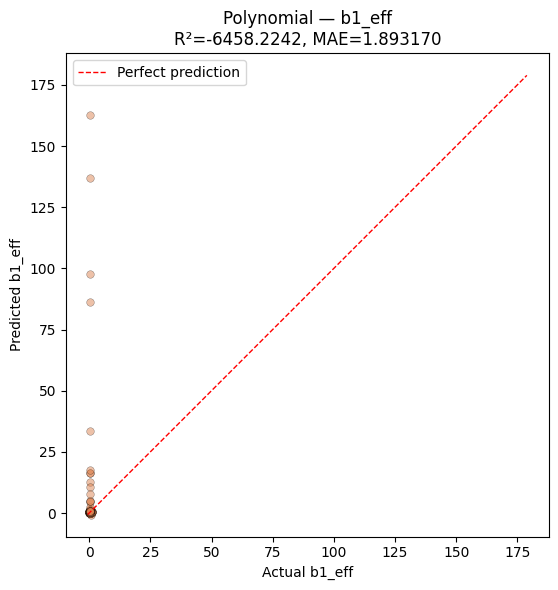

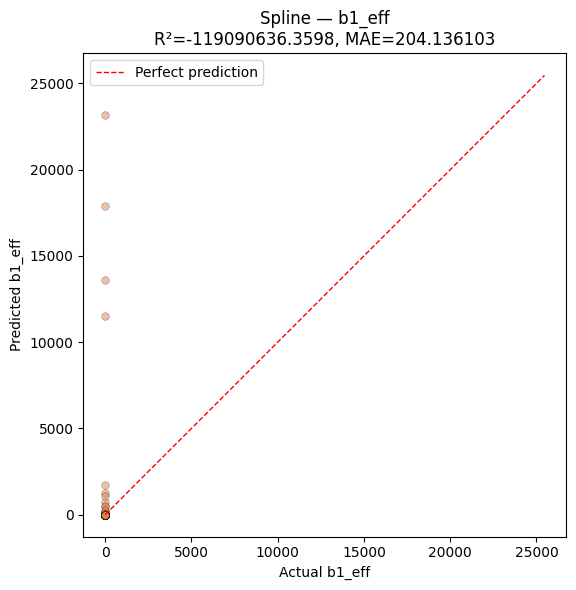

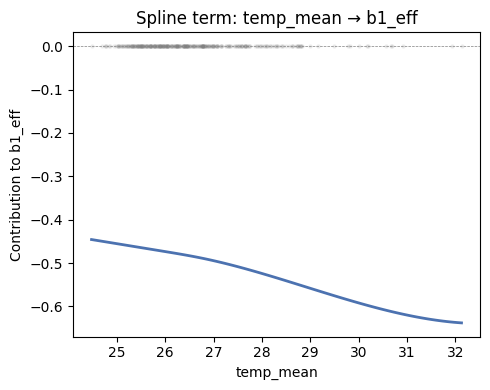

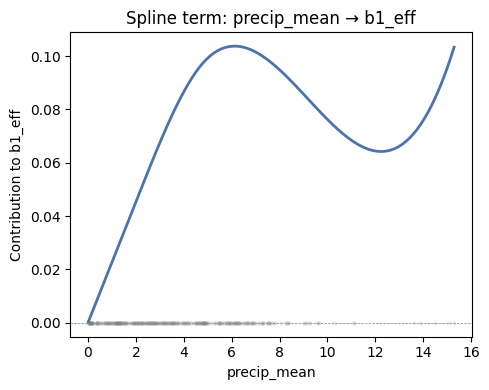

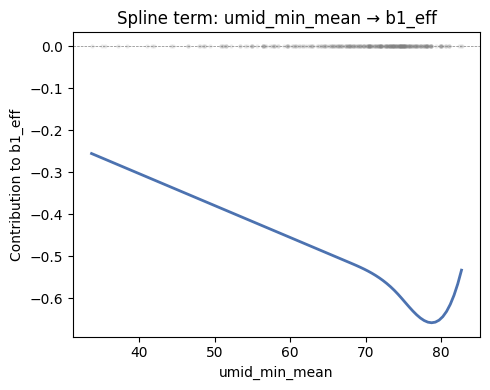

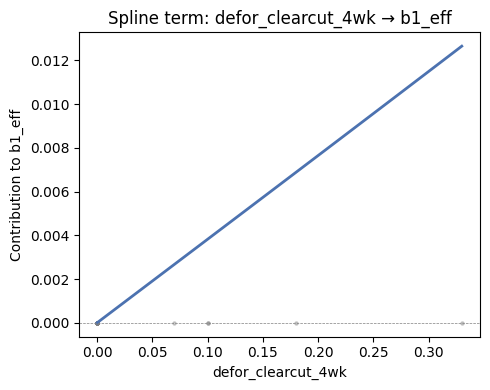

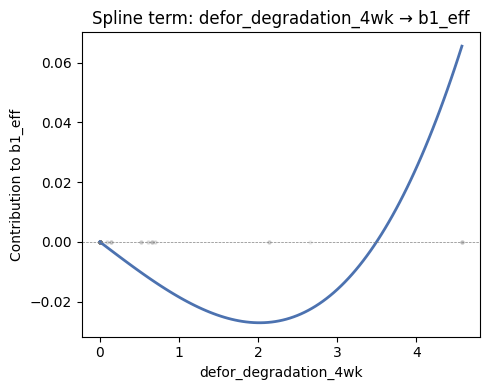

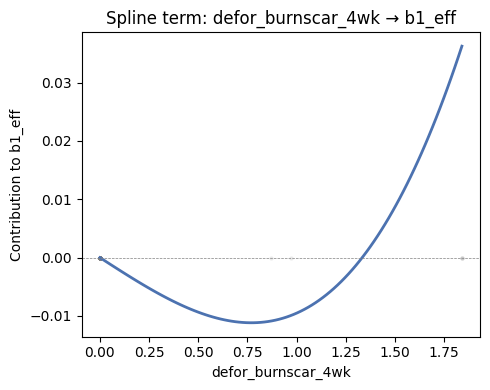

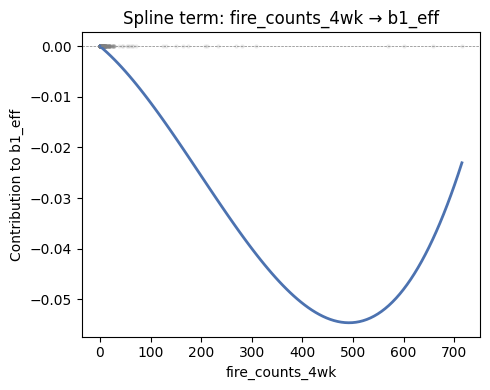

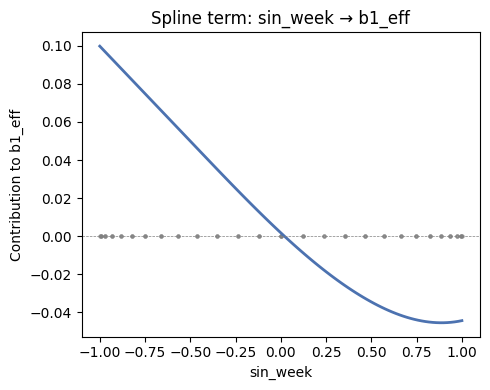

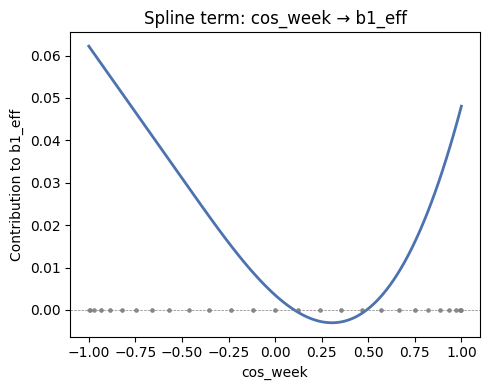

  Saved spline term plots for b1_eff


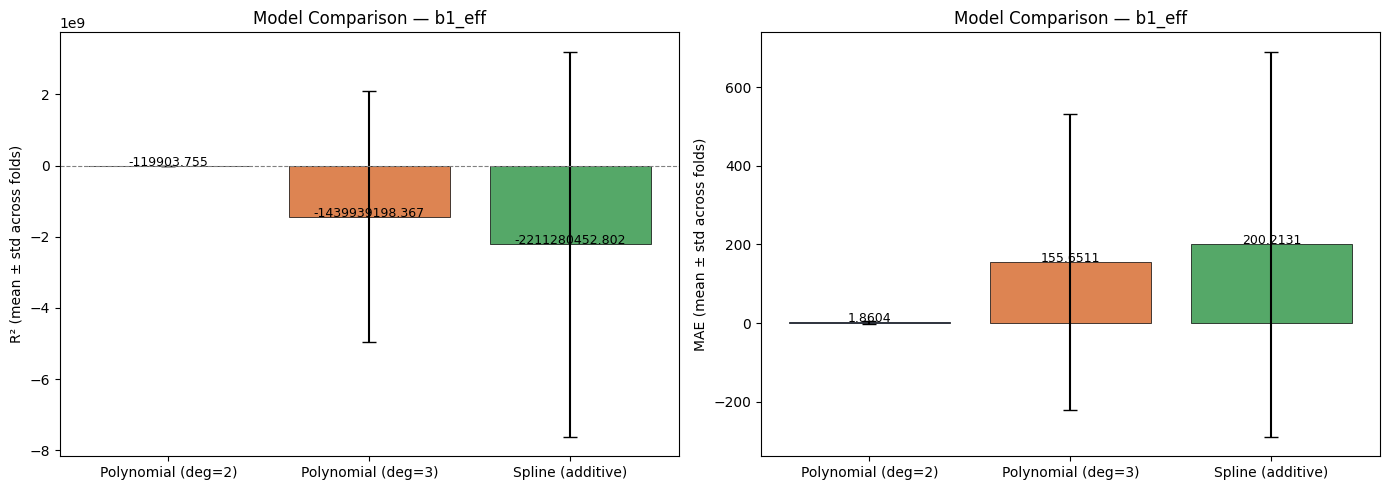


Model comparison for b2_eff

--- Polynomial (degree=2) ---
  Poly(2) Year 2017: R²=-0.2233, MAE=0.039331
  Poly(2) Year 2018: R²=-21.5631, MAE=0.190662
  Poly(2) Year 2019: R²=-5.9922, MAE=0.080530
  Poly(2) Year 2020: R²=-4.6040, MAE=0.117565
  Poly(2) Year 2021: R²=-8.5784, MAE=0.116533
  Poly(2) Year 2022: R²=-6.0700, MAE=0.132483
  Poly(2) Year 2023: R²=-170628.7879, MAE=1.416803
  Aggregate R²=-1195.3717, MAE=0.303033

--- Polynomial (degree=3) ---
  Poly(3) Year 2017: R²=-204.0247, MAE=0.711812
  Poly(3) Year 2018: R²=-375.5876, MAE=0.767218
  Poly(3) Year 2019: R²=-1113.9703, MAE=1.073550
  Poly(3) Year 2020: R²=-17.0078, MAE=0.176766
  Poly(3) Year 2021: R²=-291.0302, MAE=0.659255
  Poly(3) Year 2022: R²=-218.2904, MAE=0.747648
  Poly(3) Year 2023: R²=-49882566731.0635, MAE=637.752310
  Aggregate R²=-347663526.5459, MAE=93.483040

--- Additive Spline ---
  Spline Year 2017: R²=0.0261, MAE=0.032121
  Spline Year 2018: R²=0.5887, MAE=0.018803
  Spline Year 2019: R²=0.2302, MAE=0

C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6933396345870623e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.863692407589316e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6830914362367647e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8097119249196276e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
C:\Users\rapha\anaconda3\Lib\site

  Spline Year 2021: R²=0.2637, MAE=0.021283
  Spline Year 2022: R²=0.6464, MAE=0.023942
  Spline Year 2023: R²=-10831872097.5529, MAE=298.702404
  Aggregate R²=-75494192.9516, MAE=43.527811

Spline coefficients:
  temp_mean_s0: -0.012481
  temp_mean_s1: 0.000068
  temp_mean_s2: -0.000019
  precip_mean_s0: 0.003867
  precip_mean_s1: -0.000060
  precip_mean_s2: 0.000077
  umid_min_mean_s0: -0.003790
  umid_min_mean_s1: -0.000003
  umid_min_mean_s2: 0.000059
  defor_clearcut_4wk_s0: 0.002957
  defor_clearcut_4wk_s1: -0.000568
  defor_clearcut_4wk_s2: -0.000568
  defor_degradation_4wk_s0: -0.011866
  defor_degradation_4wk_s1: 0.000690
  defor_degradation_4wk_s2: 0.000690
  defor_burnscar_4wk_s0: -0.013008
  defor_burnscar_4wk_s1: 0.004698
  defor_burnscar_4wk_s2: 0.004698
  fire_counts_4wk_s0: -0.000887
  fire_counts_4wk_s1: 0.000000
  fire_counts_4wk_s2: -0.000000
  sin_week_s0: -0.051236
  sin_week_s1: 0.013950
  sin_week_s2: 0.002230
  cos_week_s0: -0.023179
  cos_week_s1: 0.007191
  co

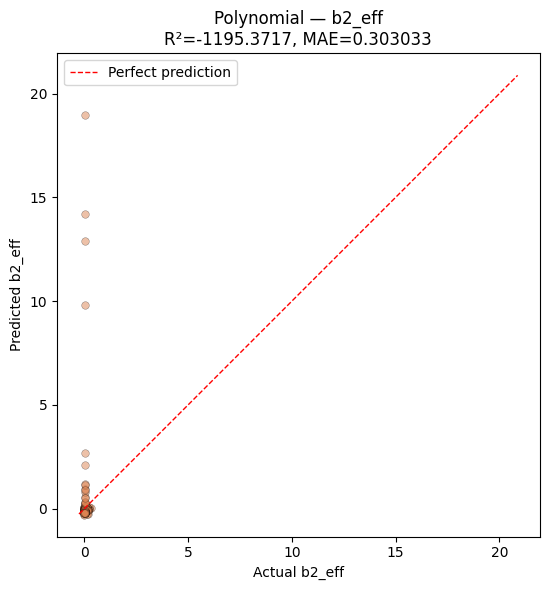

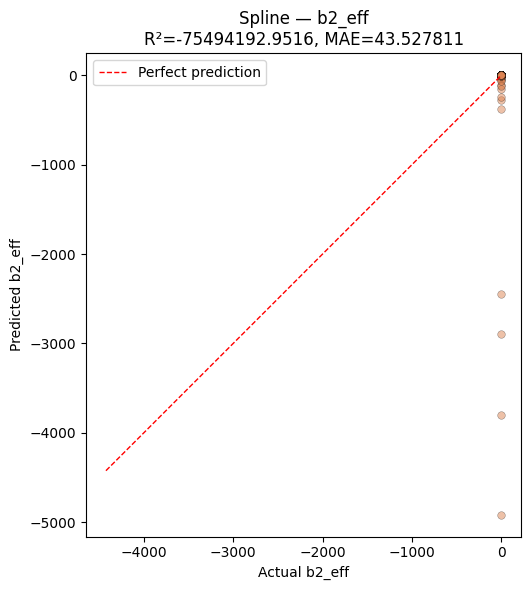

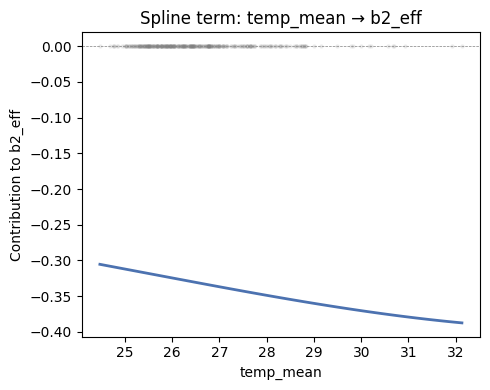

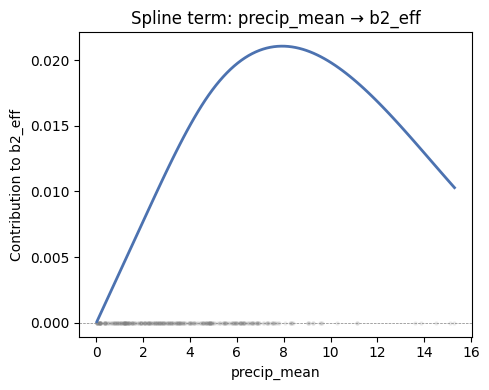

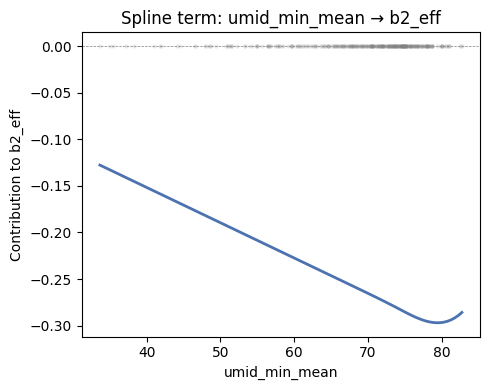

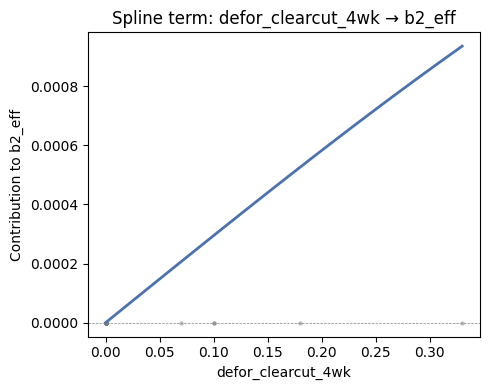

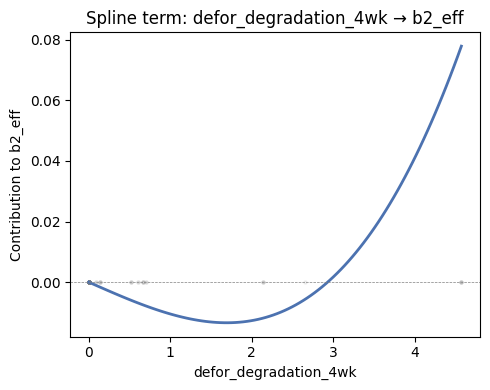

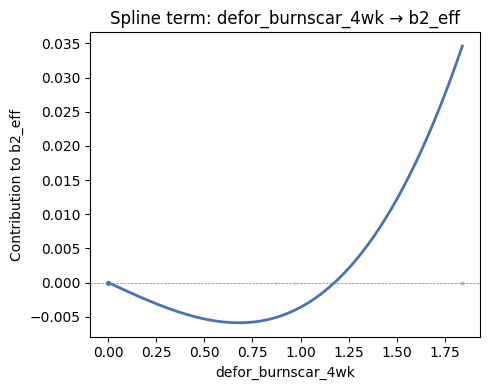

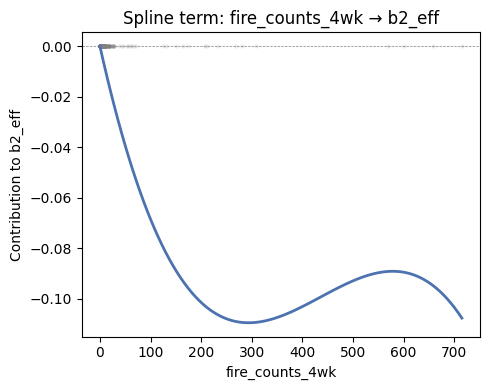

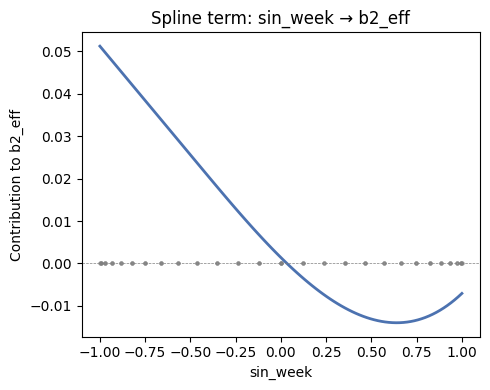

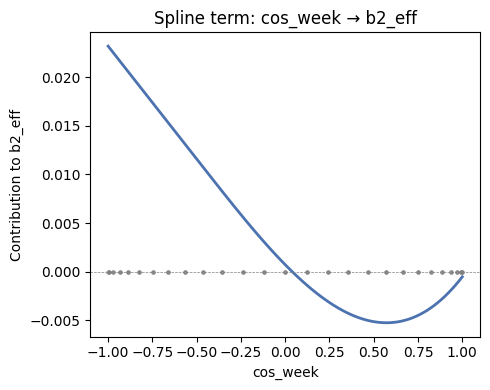

  Saved spline term plots for b2_eff


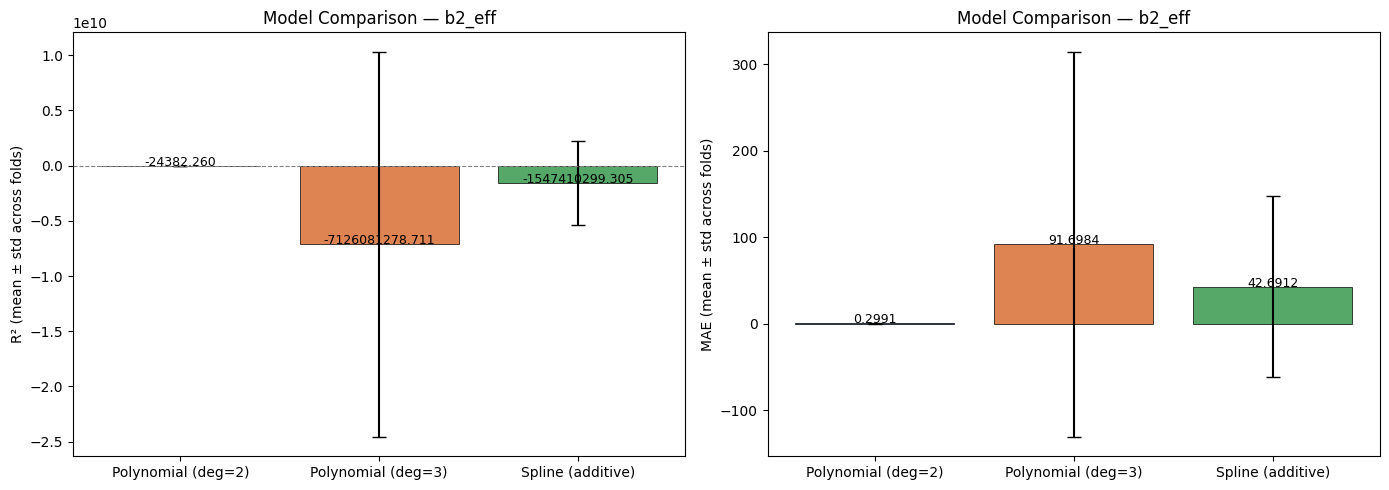


SUMMARY: All Models

b1_eff:
  Model                                  R²        MAE
  --------------------------------------------------
  Random Forest                      0.1667   0.107137
  Polynomial (deg=2)             -119903.7547   1.860360
  Polynomial (deg=3)             -1439939198.3675 155.651113
  Spline (additive)              -2211280452.8016 200.213121

b2_eff:
  Model                                  R²        MAE
  --------------------------------------------------
  Random Forest                      0.1910   0.026305
  Polynomial (deg=2)             -24382.2599   0.299129
  Polynomial (deg=3)             -7126081278.7107  91.698366
  Spline (additive)              -1547410299.3048  42.691192

SUMMARY EXCLUDING 2023

b1_eff:
  Random Forest (no 2023)        R²= -0.0501 MAE=  0.118017
  Spline (additive) (no 2023)    (see per-fold above)

b2_eff:
  Random Forest (no 2023)        R²=  0.3852 MAE=  0.022929
  Spline (additive) (no 2023)    (see per-fold above)

Done.


In [11]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    print("Loading data...")
    df = load_data()
    print(f"  {len(df)} valid weeks")

    groups = get_groups(df)
    all_comparison = {}

    for target, target_name in [(TARGET_B1, "b1_eff"), (TARGET_B2, "b2_eff")]:
        print(f"\n{'='*60}")
        print(f"Model comparison for {target_name}")
        print(f"{'='*60}")

        y = df[target].values
        X_core = df[CORE_FEATURES].values
        X_full = df[FULL_FEATURE_COLS].values

        # 1. Polynomial regression (degree 2, with year dummies)
        print("\n--- Polynomial (degree=2) ---")
        poly_results = polynomial_cv(X_full, y, groups, degree=2, alpha=1.0,
                                      target_name=target_name)
        print(f"  Aggregate R²={poly_results['overall_r2']:.4f}, MAE={poly_results['overall_mae']:.6f}")

        # 2. Polynomial regression (degree 3)
        print("\n--- Polynomial (degree=3) ---")
        poly3_results = polynomial_cv(X_full, y, groups, degree=3, alpha=10.0,
                                       target_name=target_name)
        print(f"  Aggregate R²={poly3_results['overall_r2']:.4f}, MAE={poly3_results['overall_mae']:.6f}")

        # 3. Additive spline model
        # Place knots at terciles of each feature
        print("\n--- Additive Spline ---")
        knots_dict = {}
        for i, feat in enumerate(CORE_FEATURES):
            vals = X_core[:, i]
            q33, q66 = np.percentile(vals, [33, 67])
            knots_dict[feat] = [q33, q66]

        spline_results = spline_cv(X_core, y, groups, knots_dict, alpha=1.0,
                                    target_name=target_name)
        print(f"  Aggregate R²={spline_results['overall_r2']:.4f}, MAE={spline_results['overall_mae']:.6f}")

        # Fit final spline model for coefficient extraction
        X_spline, feat_names = build_spline_features(X_core, knots_dict)
        final_spline = Ridge(alpha=1.0)
        final_spline.fit(X_spline, y)

        print("\nSpline coefficients:")
        for fname, coef in zip(feat_names, final_spline.coef_):
            print(f"  {fname}: {coef:.6f}")
        print(f"  intercept: {final_spline.intercept_:.6f}")

        # Save spline model
        spline_model_path = os.path.join(_RESULTS_DIR, f"{target_name}_spline_model.pkl")
        with open(spline_model_path, "wb") as f:
            pickle.dump({"model": final_spline, "knots": knots_dict,
                         "feature_names": CORE_FEATURES}, f)

        # Plots
        print("\nGenerating plots...")
        plot_predicted_vs_actual(poly_results, "Polynomial", target_name)
        plot_predicted_vs_actual(spline_results, "Spline", target_name)
        plot_spline_terms(final_spline, X_core, knots_dict, target_name)

        all_comparison[target_name] = {
            "Polynomial (deg=2)": {
                "mean_r2": float(poly_results["mean_r2"]),
                "std_r2": float(poly_results["std_r2"]),
                "mean_mae": float(poly_results["mean_mae"]),
                "std_mae": float(poly_results["std_mae"]),
            },
            "Polynomial (deg=3)": {
                "mean_r2": float(poly3_results["mean_r2"]),
                "std_r2": float(poly3_results["std_r2"]),
                "mean_mae": float(poly3_results["mean_mae"]),
                "std_mae": float(poly3_results["std_mae"]),
            },
            "Spline (additive)": {
                "mean_r2": float(spline_results["mean_r2"]),
                "std_r2": float(spline_results["std_r2"]),
                "mean_mae": float(spline_results["mean_mae"]),
                "std_mae": float(spline_results["std_mae"]),
            },
        }

        plot_model_comparison(all_comparison[target_name], target_name)

    # Save comparison table
    comparison_path = os.path.join(_RESULTS_DIR, "model_comparison_metrics.json")
    with open(comparison_path, "w") as f:
        json.dump(all_comparison, f, indent=2)

    # Also load RF metrics and print summary
    rf_path = os.path.join(_RESULTS_DIR, "rf_cv_metrics.json")
    if os.path.exists(rf_path):
        with open(rf_path) as f:
            rf_metrics = json.load(f)
        print("\n" + "="*60)
        print("SUMMARY: All Models")
        print("="*60)
        for target_name in ["b1_eff", "b2_eff"]:
            print(f"\n{target_name}:")
            print(f"  {'Model':<30s} {'R²':>10s} {'MAE':>10s}")
            print(f"  {'-'*50}")
            # RF
            print(f"  {'Random Forest':<30s} {rf_metrics[target_name]['overall_r2']:>10.4f} "
                  f"{rf_metrics[target_name]['overall_mae']:>10.6f}")
            # Others
            for model_name, vals in all_comparison[target_name].items():
                print(f"  {model_name:<30s} {vals['mean_r2']:>10.4f} {vals['mean_mae']:>10.6f}")

    # Excluding 2023 summary (2023 is an outlier year for b2)
    print("\n" + "="*60)
    print("SUMMARY EXCLUDING 2023")
    print("="*60)
    for target_name in ["b1_eff", "b2_eff"]:
        print(f"\n{target_name}:")
        # RF per-year excluding 2023
        rf_data = rf_metrics[target_name]
        non_2023 = [i for i, y in enumerate(rf_data["fold_years"]) if y != 2023]
        rf_r2_no2023 = np.mean([rf_data["fold_r2"][i] for i in non_2023])
        rf_mae_no2023 = np.mean([rf_data["fold_mae"][i] for i in non_2023])
        print(f"  {'Random Forest (no 2023)':<30s} R²={rf_r2_no2023:>8.4f} MAE={rf_mae_no2023:>10.6f}")
        # Spline per-year
        for model_name, vals in all_comparison[target_name].items():
            if "Spline" in model_name:
                # Re-compute from stored fold data
                print(f"  {model_name+' (no 2023)':<30s} (see per-fold above)")

    print("\nDone.")


main()